# Notebook 06 — Farmer Crop & Market Recommendation System

**Objective:** Give Kenya farmers actionable intelligence by combining three data sources:
1. NASA (National Aeronautics and Space Administration) POWER weather data → is my county suitable for growing this crop right now?
2. WFP (World Food Programme) market price data → which market is offering the best price?
3. FEWS NET IPC (Integrated Food Security Phase Classification) data → what is my county's food security risk?

**Approach:** Content-based filtering — match county weather profile against crop climate requirements, then rank by suitability score and WFP (World Food Programme) market price.

**Output:** For any Kenyan county → top crop recommendations + best market + current price per kg


In [26]:
import os
project_root = r"C:\Users\HomePC\Desktop\kenya-smart-agriculture"
os.chdir(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

os.makedirs("figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("Libraries loaded ✅")

Libraries loaded ✅


## Step 1 — Load All Datasets

In [27]:
# Load NASA (National Aeronautics and Space Administration) master + IPC (Integrated Food Security Phase Classification)
master = pd.read_csv("data/processed/master_dataset.csv")
ipc    = pd.read_csv("data/processed/ipc_county.csv")
nasa   = pd.read_csv("data/processed/nasa_monthly_clean.csv")

# Load WFP (World Food Programme) price and market data
wfp_prices  = pd.read_csv("data/raw/prices/wfp_food_prices_ken.csv", low_memory=False)
wfp_markets = pd.read_csv("data/raw/prices/wfp_markets_ken.csv")

wfp_prices["date"] = pd.to_datetime(wfp_prices["date"])
wfp_prices["admin1"] = wfp_prices["admin1"].fillna("Unknown")

print(f"Master dataset              : {master.shape}")
print(f"IPC (Integrated Food Security Phase Classification) county         : {ipc.shape}")
print(f"WFP (World Food Programme) prices              : {wfp_prices.shape}")
print(f"WFP (World Food Programme) markets             : {wfp_markets.shape}")
print(f"\nWFP (World Food Programme) date range: {wfp_prices['date'].min().date()} → {wfp_prices['date'].max().date()}")
print(f"WFP (World Food Programme) markets   : {wfp_prices['market'].nunique()}")
print(f"WFP (World Food Programme) commodities: {wfp_prices['commodity'].nunique()}")


Master dataset              : (13464, 23)
IPC (Integrated Food Security Phase Classification) county         : (47, 7)
WFP (World Food Programme) prices              : (19005, 16)
WFP (World Food Programme) markets             : (280, 7)

WFP (World Food Programme) date range: 2006-01-15 → 2026-03-15
WFP (World Food Programme) markets   : 226
WFP (World Food Programme) commodities: 51


## Step 2 — County to WFP (World Food Programme) Region Mapping

WFP (World Food Programme) uses Kenya's old 8 provinces. We map each county to its province for price lookups.

In [28]:
# Map all 47 counties to WFP (World Food Programme) regions (old Kenya provinces)
COUNTY_TO_WFP_REGION = {
    # Central
    "Kiambu": "Central", "Muranga": "Central", "Nyeri": "Central",
    "Kirinyaga": "Central", "Nyandarua": "Central",
    # Coast
    "Mombasa": "Coast", "Kwale": "Coast", "Kilifi": "Coast",
    "Tana River": "Coast", "Lamu": "Coast", "Taita Taveta": "Coast",
    # Eastern
    "Machakos": "Eastern", "Makueni": "Eastern", "Kitui": "Eastern",
    "Meru": "Eastern", "Tharaka Nithi": "Eastern", "Embu": "Eastern",
    "Marsabit": "Eastern", "Isiolo": "Eastern",
    # Nairobi
    "Nairobi": "Nairobi",
    # North Eastern
    "Garissa": "North Eastern", "Wajir": "North Eastern", "Mandera": "North Eastern",
    # Nyanza
    "Kisumu": "Nyanza", "Siaya": "Nyanza", "Homa Bay": "Nyanza",
    "Migori": "Nyanza", "Kisii": "Nyanza", "Nyamira": "Nyanza",
    # Rift Valley
    "Turkana": "Rift Valley", "West Pokot": "Rift Valley", "Samburu": "Rift Valley",
    "Trans Nzoia": "Rift Valley", "Uasin Gishu": "Rift Valley",
    "Elgeyo Marakwet": "Rift Valley", "Nandi": "Rift Valley",
    "Baringo": "Rift Valley", "Laikipia": "Rift Valley", "Nakuru": "Rift Valley",
    "Narok": "Rift Valley", "Kajiado": "Rift Valley", "Kericho": "Rift Valley",
    "Bomet": "Rift Valley",
    # Western (mapped to Rift Valley — closest in WFP data)
    "Kakamega": "Rift Valley", "Vihiga": "Rift Valley",
    "Bungoma": "Rift Valley", "Busia": "Rift Valley",
}

print("County → WFP (World Food Programme) Region mapping created ✅")
print(f"Counties mapped: {len(COUNTY_TO_WFP_REGION)}")
print(f"Regions available: {sorted(set(COUNTY_TO_WFP_REGION.values()))}")

County → WFP (World Food Programme) Region mapping created ✅
Counties mapped: 47
Regions available: ['Central', 'Coast', 'Eastern', 'Nairobi', 'North Eastern', 'Nyanza', 'Rift Valley']


## Step 3 — Crop Climate Requirements Database

Define the weather conditions each crop needs to grow well in Kenya.

In [29]:
# Crop climate requirements for Kenya's main food and cash crops
# Sources: KALRO (Kenya Agricultural and Livestock Research Organisation) crop guides,
#          FAO (Food and Agriculture Organisation) crop requirements
CROPS = {
    "Maize": {
        "rainfall_min_mm": 400, "rainfall_max_mm": 900,
        "temp_min_c": 18, "temp_max_c": 27,
        "seasons": ["MAM", "OND"],
        "drought_tolerant": False,
        "description": "Kenya's staple food crop — best in medium-high rainfall areas",
    },
    "Sorghum": {
        "rainfall_min_mm": 200, "rainfall_max_mm": 600,
        "temp_min_c": 20, "temp_max_c": 35,
        "seasons": ["MAM", "OND"],
        "drought_tolerant": True,
        "description": "Drought-tolerant alternative to maize — ideal for arid counties",
    },
    "Millet (Finger)": {
        "rainfall_min_mm": 200, "rainfall_max_mm": 500,
        "temp_min_c": 18, "temp_max_c": 35,
        "seasons": ["MAM"],
        "drought_tolerant": True,
        "description": "Very drought-tolerant — good for northern arid counties",
    },
    "Beans": {
        "rainfall_min_mm": 300, "rainfall_max_mm": 600,
        "temp_min_c": 15, "temp_max_c": 25,
        "seasons": ["MAM", "OND"],
        "drought_tolerant": False,
        "description": "High protein crop — grows well in highland and midland areas",
    },
    "Cowpeas": {
        "rainfall_min_mm": 200, "rainfall_max_mm": 700,
        "temp_min_c": 20, "temp_max_c": 35,
        "seasons": ["MAM", "OND"],
        "drought_tolerant": True,
        "description": "Drought tolerant legume — good for semi-arid zones",
    },
    "Cassava": {
        "rainfall_min_mm": 100, "rainfall_max_mm": 1500,
        "temp_min_c": 25, "temp_max_c": 35,
        "seasons": ["MAM", "OND", "DS1", "DS2"],
        "drought_tolerant": True,
        "description": "Extremely drought-tolerant root crop — good for arid and coastal areas",
    },
    "Sweet Potato": {
        "rainfall_min_mm": 400, "rainfall_max_mm": 1000,
        "temp_min_c": 20, "temp_max_c": 30,
        "seasons": ["MAM", "OND"],
        "drought_tolerant": False,
        "description": "Nutritious root crop — suits well-watered areas",
    },
    "Potatoes (Irish)": {
        "rainfall_min_mm": 500, "rainfall_max_mm": 1200,
        "temp_min_c": 10, "temp_max_c": 20,
        "seasons": ["MAM", "OND"],
        "drought_tolerant": False,
        "description": "Highland crop — best in cool, high-rainfall areas like Nyandarua, Nakuru",
    },
    "Kale (Sukuma Wiki)": {
        "rainfall_min_mm": 300, "rainfall_max_mm": 1000,
        "temp_min_c": 15, "temp_max_c": 25,
        "seasons": ["MAM", "OND", "DS1", "DS2"],
        "drought_tolerant": False,
        "description": "Year-round vegetable — widely grown across Kenya",
    },
    "Pigeon Peas": {
        "rainfall_min_mm": 250, "rainfall_max_mm": 700,
        "temp_min_c": 18, "temp_max_c": 35,
        "seasons": ["MAM"],
        "drought_tolerant": True,
        "description": "Drought-tolerant legume — good for coastal and eastern counties",
    },
}

print(f"Crop database loaded: {len(CROPS)} crops")
for crop, info in CROPS.items():
    print(f"  {crop:<20} Rainfall: {info['rainfall_min_mm']}–{info['rainfall_max_mm']}mm  "
          f"Temp: {info['temp_min_c']}–{info['temp_max_c']}°C  "
          f"Drought tolerant: {info['drought_tolerant']}")

Crop database loaded: 10 crops
  Maize                Rainfall: 400–900mm  Temp: 18–27°C  Drought tolerant: False
  Sorghum              Rainfall: 200–600mm  Temp: 20–35°C  Drought tolerant: True
  Millet (Finger)      Rainfall: 200–500mm  Temp: 18–35°C  Drought tolerant: True
  Beans                Rainfall: 300–600mm  Temp: 15–25°C  Drought tolerant: False
  Cowpeas              Rainfall: 200–700mm  Temp: 20–35°C  Drought tolerant: True
  Cassava              Rainfall: 100–1500mm  Temp: 25–35°C  Drought tolerant: True
  Sweet Potato         Rainfall: 400–1000mm  Temp: 20–30°C  Drought tolerant: False
  Potatoes (Irish)     Rainfall: 500–1200mm  Temp: 10–20°C  Drought tolerant: False
  Kale (Sukuma Wiki)   Rainfall: 300–1000mm  Temp: 15–25°C  Drought tolerant: False
  Pigeon Peas          Rainfall: 250–700mm  Temp: 18–35°C  Drought tolerant: True


## Step 4 — County Weather Profile (Current Season)

Get each county's weather conditions for the most recent season.

In [30]:
# Build county profiles using most recent 3 years of NASA data (2021-2023)
recent_nasa = nasa[nasa["year"] >= 2021].copy()

county_weather = (
    recent_nasa.groupby("county").agg(
        avg_monthly_rainfall = ("total_rainfall", "mean"),
        annual_rainfall      = ("total_rainfall", lambda x: x.mean() * 12),
        mean_temp            = ("mean_temp", "mean"),
        max_temp             = ("max_temp", "mean"),
        drought_frequency    = ("drought_flag", "mean"),
        spi_3_mean           = ("spi_3", "mean"),
        dry_days_mean        = ("dry_days", "mean"),
    ).reset_index()
)

# Add seasonal rainfall
mam_rain = (recent_nasa[recent_nasa["season"] == "MAM"]
            .groupby("county")["total_rainfall"].mean()
            .reset_index()
            .rename(columns={"total_rainfall": "mam_rainfall"}))
ond_rain = (recent_nasa[recent_nasa["season"] == "OND"]
            .groupby("county")["total_rainfall"].mean()
            .reset_index()
            .rename(columns={"total_rainfall": "ond_rainfall"}))

county_weather = county_weather.merge(mam_rain, on="county", how="left")
county_weather = county_weather.merge(ond_rain, on="county", how="left")

# Add IPC (Integrated Food Security Phase Classification) phase and WFP (World Food Programme) region
ipc_simple = ipc[["county", "ipc_phase", "ipc_phase_label"]].copy()
county_weather = county_weather.merge(ipc_simple, on="county", how="left")
county_weather["wfp_region"] = county_weather["county"].map(COUNTY_TO_WFP_REGION)

print(f"County weather profiles: {county_weather.shape}")
print()
print(county_weather[["county","annual_rainfall","mean_temp","drought_frequency",
                       "ipc_phase_label","wfp_region"]].head(10).to_string(index=False))

County weather profiles: (46, 13)

         county  annual_rainfall  mean_temp  drought_frequency ipc_phase_label    wfp_region
        Baringo       946.496667  22.178557           0.361111        Stressed   Rift Valley
        Bungoma      1705.646667  22.167991           0.361111         Minimal   Rift Valley
          Busia      1705.646667  22.167991           0.361111         Minimal   Rift Valley
Elgeyo Marakwet       411.173333  21.258390           0.861111         Minimal   Rift Valley
           Embu      1099.333333  20.373549           0.388889        Stressed       Eastern
        Garissa       619.600000  27.673372           0.805556          Crisis North Eastern
       Homa Bay      2287.790000  23.677564           0.222222         Minimal        Nyanza
         Isiolo       888.503333  22.936083           0.638889          Crisis       Eastern
        Kajiado       521.916667  20.702851           0.861111        Stressed   Rift Valley
       Kakamega      2105.096667  1

## Step 5 — Crop Suitability Scoring Function

In [31]:
def score_crop_suitability(county_name, season="MAM"):
    """
    Score all crops for a given county and season.

    Args:
        county_name: Name of the Kenya county
        season: 'MAM' (March-April-May long rains) or
                'OND' (October-November-December short rains)

    Returns:
        DataFrame of crops ranked by suitability score (0-100)
    """
    county = county_weather[county_weather["county"] == county_name]
    if county.empty:
        print(f"County '{county_name}' not found")
        return pd.DataFrame()

    row = county.iloc[0]

    # Use seasonal rainfall if available
    if season == "MAM":
        rainfall = row.get("mam_rainfall", row["avg_monthly_rainfall"] * 3)
    else:
        rainfall = row.get("ond_rainfall", row["avg_monthly_rainfall"] * 3)

    temp      = row["mean_temp"]
    drought_f = row["drought_frequency"]

    scores = []
    for crop_name, req in CROPS.items():
        # Skip crops not suited for this season
        if season not in req["seasons"]:
            continue

        score = 0

        # Rainfall suitability (40% of score)
        if req["rainfall_min_mm"] <= rainfall <= req["rainfall_max_mm"]:
            rain_score = 40
        elif rainfall < req["rainfall_min_mm"]:
            deficit = req["rainfall_min_mm"] - rainfall
            rain_score = max(0, 40 - (deficit / req["rainfall_min_mm"]) * 40)
        else:
            excess = rainfall - req["rainfall_max_mm"]
            rain_score = max(0, 40 - (excess / req["rainfall_max_mm"]) * 20)

        # Temperature suitability (35% of score)
        if req["temp_min_c"] <= temp <= req["temp_max_c"]:
            temp_score = 35
        elif temp < req["temp_min_c"]:
            temp_score = max(0, 35 - (req["temp_min_c"] - temp) * 5)
        else:
            temp_score = max(0, 35 - (temp - req["temp_max_c"]) * 5)

        # Drought tolerance bonus (25% of score)
        if req["drought_tolerant"] and drought_f > 0.3:
            drought_score = 25  # Bonus for drought-tolerant crops in dry areas
        elif not req["drought_tolerant"] and drought_f <= 0.2:
            drought_score = 25  # Good conditions for non-tolerant crops
        elif not req["drought_tolerant"] and drought_f > 0.5:
            drought_score = 0   # High drought risk for sensitive crops
        else:
            drought_score = 12

        total_score = rain_score + temp_score + drought_score

        scores.append({
            "crop":              crop_name,
            "suitability_score": round(total_score, 1),
            "rainfall_mm":       round(rainfall, 1),
            "temperature_c":     round(temp, 1),
            "drought_tolerant":  req["drought_tolerant"],
            "description":       req["description"],
        })

    result = pd.DataFrame(scores).sort_values(
        "suitability_score", ascending=False
    ).reset_index(drop=True)
    result["rank"] = result.index + 1
    return result


# Test
print("Crop suitability for Turkana (arid, high drought) — MAM season:")
print(score_crop_suitability("Turkana", "MAM")[
    ["rank","crop","suitability_score","drought_tolerant"]].head(5).to_string(index=False))

print("\nCrop suitability for Nakuru (good rainfall, cool) — MAM season:")
print(score_crop_suitability("Nakuru", "MAM")[
    ["rank","crop","suitability_score","drought_tolerant"]].head(5).to_string(index=False))

Crop suitability for Turkana (arid, high drought) — MAM season:
 rank            crop  suitability_score  drought_tolerant
    1         Cassava               72.7              True
    2         Sorghum               66.4              True
    3         Cowpeas               66.4              True
    4 Millet (Finger)               66.4              True
    5     Pigeon Peas               65.1              True

Crop suitability for Nakuru (good rainfall, cool) — MAM season:
 rank               crop  suitability_score  drought_tolerant
    1    Millet (Finger)               79.7              True
    2        Pigeon Peas               73.1              True
    3            Cowpeas               69.7              True
    4            Sorghum               69.7              True
    5 Kale (Sukuma Wiki)               69.0             False


In [32]:
print(county_weather[county_weather["county"] == "Nakuru"][
    ["county","annual_rainfall","mean_temp","drought_frequency","ipc_phase_label"]
].to_string(index=False))

county  annual_rainfall  mean_temp  drought_frequency ipc_phase_label
Nakuru      1419.446667  15.356573           0.305556         Minimal


In [33]:
# Check Potatoes score for Nakuru specifically
nakuru = county_weather[county_weather["county"] == "Nakuru"].iloc[0]
print(f"Annual rainfall: {nakuru['annual_rainfall']:.0f}mm")
print(f"Seasonal MAM rainfall: {nakuru['mam_rainfall']:.0f}mm")
print(f"Mean temp: {nakuru['mean_temp']:.1f}°C")
print(f"Drought frequency: {nakuru['drought_frequency']:.2f}")

# Potatoes requires 500-1200mm seasonal and 10-20°C
print(f"\nPotatoes requirement: 500-1200mm rainfall, 10-20°C")
print(f"Nakuru MAM rainfall vs requirement: {nakuru['mam_rainfall']:.0f}mm (needs 500-1200mm)")
print(f"Nakuru temp vs requirement: {nakuru['mean_temp']:.1f}°C (needs 10-20°C)")

Annual rainfall: 1419mm
Seasonal MAM rainfall: 165mm
Mean temp: 15.4°C
Drought frequency: 0.31

Potatoes requirement: 500-1200mm rainfall, 10-20°C
Nakuru MAM rainfall vs requirement: 165mm (needs 500-1200mm)
Nakuru temp vs requirement: 15.4°C (needs 10-20°C)


In [34]:
# Fix crop requirements to use SEASONAL rainfall (3 months)
# Divide annual requirements by 3 to get seasonal equivalents
CROPS_FIXED = {
    "Maize":           {"rainfall_min_mm": 150, "rainfall_max_mm": 350,
                        "temp_min_c": 18, "temp_max_c": 27, "seasons": ["MAM","OND"], "drought_tolerant": False,
                        "description": "Kenya's staple food crop — best in medium-high rainfall areas"},
    "Sorghum":         {"rainfall_min_mm": 70,  "rainfall_max_mm": 220,
                        "temp_min_c": 20, "temp_max_c": 35, "seasons": ["MAM","OND"], "drought_tolerant": True,
                        "description": "Drought-tolerant alternative to maize — ideal for arid counties"},
    "Millet (Finger)": {"rainfall_min_mm": 60,  "rainfall_max_mm": 180,
                        "temp_min_c": 18, "temp_max_c": 35, "seasons": ["MAM"], "drought_tolerant": True,
                        "description": "Very drought-tolerant — good for northern arid counties"},
    "Beans":           {"rainfall_min_mm": 100, "rainfall_max_mm": 220,
                        "temp_min_c": 15, "temp_max_c": 25, "seasons": ["MAM","OND"], "drought_tolerant": False,
                        "description": "High protein crop — grows well in highland and midland areas"},
    "Cowpeas":         {"rainfall_min_mm": 70,  "rainfall_max_mm": 250,
                        "temp_min_c": 20, "temp_max_c": 35, "seasons": ["MAM","OND"], "drought_tolerant": True,
                        "description": "Drought tolerant legume — good for semi-arid zones"},
    "Cassava":         {"rainfall_min_mm": 30,  "rainfall_max_mm": 500,
                        "temp_min_c": 25, "temp_max_c": 35, "seasons": ["MAM","OND","DS1","DS2"], "drought_tolerant": True,
                        "description": "Extremely drought-tolerant root crop — good for arid and coastal areas"},
    "Sweet Potato":    {"rainfall_min_mm": 130, "rainfall_max_mm": 350,
                        "temp_min_c": 20, "temp_max_c": 30, "seasons": ["MAM","OND"], "drought_tolerant": False,
                        "description": "Nutritious root crop — suits well-watered areas"},
    "Potatoes (Irish)":{"rainfall_min_mm": 150, "rainfall_max_mm": 400,
                        "temp_min_c": 10, "temp_max_c": 20, "seasons": ["MAM","OND"], "drought_tolerant": False,
                        "description": "Highland crop — best in cool, high-rainfall areas like Nyandarua, Nakuru"},
    "Kale (Sukuma Wiki)":{"rainfall_min_mm": 100, "rainfall_max_mm": 350,
                          "temp_min_c": 15, "temp_max_c": 25, "seasons": ["MAM","OND","DS1","DS2"], "drought_tolerant": False,
                          "description": "Year-round vegetable — widely grown across Kenya"},
    "Pigeon Peas":     {"rainfall_min_mm": 80,  "rainfall_max_mm": 250,
                        "temp_min_c": 18, "temp_max_c": 35, "seasons": ["MAM"], "drought_tolerant": True,
                        "description": "Drought-tolerant legume — good for coastal and eastern counties"},
}

# Replace the original CROPS with fixed version
CROPS = CROPS_FIXED

# Retest
print("Crop suitability for Nakuru — MAM season (fixed):")
print(score_crop_suitability("Nakuru", "MAM")[
    ["rank","crop","suitability_score","drought_tolerant"]].head(6).to_string(index=False))

print("\nCrop suitability for Turkana — MAM season (fixed):")
print(score_crop_suitability("Turkana", "MAM")[
    ["rank","crop","suitability_score","drought_tolerant"]].head(6).to_string(index=False))

print("\nCrop suitability for Kiambu — MAM season (fixed):")
print(score_crop_suitability("Kiambu", "MAM")[
    ["rank","crop","suitability_score","drought_tolerant"]].head(6).to_string(index=False))

Crop suitability for Nakuru — MAM season (fixed):
 rank               crop  suitability_score  drought_tolerant
    1   Potatoes (Irish)               87.0             False
    2              Beans               87.0             False
    3 Kale (Sukuma Wiki)               87.0             False
    4    Millet (Finger)               86.8              True
    5        Pigeon Peas               86.8              True
    6            Sorghum               76.8              True

Crop suitability for Turkana — MAM season (fixed):
 rank            crop  suitability_score  drought_tolerant
    1         Cassava              100.0              True
    2 Millet (Finger)               81.2              True
    3         Cowpeas               78.2              True
    4         Sorghum               78.2              True
    5     Pigeon Peas               75.9              True
    6    Sweet Potato               44.8             False

Crop suitability for Kiambu — MAM season (fixed):


## Step 6 — WFP (World Food Programme) Market Price Lookup

In [35]:
# Map crop names to WFP (World Food Programme) commodity names
CROP_TO_WFP = {
    "Maize":           ["Maize", "Maize (white, dry)", "Maize (white)"],
    "Sorghum":         ["Sorghum", "Sorghum (white)", "Sorghum (red)"],
    "Millet (Finger)": ["Millet (finger)"],
    "Beans":           ["Beans", "Beans (dry)", "Beans (rosecoco)"],
    "Cowpeas":         ["Cowpeas", "Cowpeas (dry)"],
    "Cassava":         [],  # Not in WFP data
    "Sweet Potato":    [],  # Not in WFP data
    "Potatoes (Irish)":["Potatoes (Irish)", "Potatoes (Irish, white)", "Potatoes (Irish, red)"],
    "Kale (Sukuma Wiki)":["Kale"],
    "Pigeon Peas":     ["Pigeon peas (dry)"],
}

def get_market_price(crop_name, wfp_region, months_back=6):
    """
    Get recent average market price for a crop in a given WFP (World Food Programme) region.

    Args:
        crop_name: Crop name from CROPS database
        wfp_region: WFP (World Food Programme) region name (old Kenya province)
        months_back: How many recent months to average

    Returns:
        Dict with price info and market details
    """
    wfp_names = CROP_TO_WFP.get(crop_name, [])
    if not wfp_names:
        return {"price_kes": None, "market": None, "trend": None}

    # Get recent prices for this region and crop
    cutoff = wfp_prices["date"].max() - pd.DateOffset(months=months_back)
    mask = (
        (wfp_prices["admin1"] == wfp_region) &
        (wfp_prices["commodity"].isin(wfp_names)) &
        (wfp_prices["date"] >= cutoff) &
        (wfp_prices["pricetype"] == "Retail")
    )
    recent = wfp_prices[mask]

    # Fallback to wholesale if no retail
    if recent.empty:
        mask2 = (
            (wfp_prices["admin1"] == wfp_region) &
            (wfp_prices["commodity"].isin(wfp_names)) &
            (wfp_prices["date"] >= cutoff)
        )
        recent = wfp_prices[mask2]

    # Fallback to national if no regional
    if recent.empty:
        mask3 = (
            (wfp_prices["commodity"].isin(wfp_names)) &
            (wfp_prices["date"] >= cutoff)
        )
        recent = wfp_prices[mask3]

    if recent.empty:
        return {"price_kes": None, "market": "Not available", "trend": None}

    avg_price   = recent["price"].mean()
    best_market = recent.loc[recent["price"].idxmax(), "market"]

    # Trend: compare last 3 months to previous 3 months
    mid = cutoff + pd.DateOffset(months=months_back // 2)
    recent_3m = recent[recent["date"] >= mid]["price"].mean()
    older_3m  = recent[recent["date"] < mid]["price"].mean()
    if pd.notna(recent_3m) and pd.notna(older_3m) and older_3m > 0:
        trend = "Rising ↑" if recent_3m > older_3m * 1.03 else (
                "Falling ↓" if recent_3m < older_3m * 0.97 else "Stable →")
    else:
        trend = "Stable →"

    return {
        "price_kes":     round(avg_price, 2),
        "best_market":   best_market,
        "trend":         trend,
        "data_points":   len(recent),
    }

# Test
print("Maize price in Rift Valley:")
print(get_market_price("Maize", "Rift Valley"))
print("\nBeans price in Nairobi:")
print(get_market_price("Beans", "Nairobi"))


Maize price in Rift Valley:
{'price_kes': np.float64(70.53), 'best_market': 'Lorugum', 'trend': 'Falling ↓', 'data_points': 31}

Beans price in Nairobi:
{'price_kes': np.float64(10566.67), 'best_market': 'Kangemi (Nairobi)', 'trend': 'Rising ↑', 'data_points': 3}


In [36]:
# Check what unit the beans prices are in for Nairobi
beans_nairobi = wfp_prices[
    (wfp_prices["admin1"] == "Nairobi") &
    (wfp_prices["commodity"].isin(["Beans", "Beans (dry)"])) &
    (wfp_prices["date"] >= "2024-01-01")
][["date","commodity","unit","pricetype","price","market"]].head(10)
print(beans_nairobi.to_string(index=False))

Empty DataFrame
Columns: [date, commodity, unit, pricetype, price, market]
Index: []


In [37]:
# Fix unit normalisation — convert bulk bag prices to per kg
def normalise_price_per_kg(df):
    df = df.copy()
    # 90kg bag → divide by 90
    mask_90 = df["unit"].str.contains("90 KG", case=False, na=False)
    df.loc[mask_90, "price"] = df.loc[mask_90, "price"] / 90
    # 100kg bag → divide by 100
    mask_100 = df["unit"].str.contains("100 KG", case=False, na=False)
    df.loc[mask_100, "price"] = df.loc[mask_100, "price"] / 100
    return df

wfp_prices = normalise_price_per_kg(wfp_prices)

# Retest
print("Beans price in Nairobi (after unit fix):")
print(get_market_price("Beans", "Nairobi"))

print("\nMaize price in Rift Valley:")
print(get_market_price("Maize", "Rift Valley"))

print("\nSorghum price in North Eastern:")
print(get_market_price("Sorghum", "North Eastern"))

Beans price in Nairobi (after unit fix):
{'price_kes': np.float64(117.41), 'best_market': 'Kangemi (Nairobi)', 'trend': 'Rising ↑', 'data_points': 3}

Maize price in Rift Valley:
{'price_kes': np.float64(70.53), 'best_market': 'Lorugum', 'trend': 'Falling ↓', 'data_points': 31}

Sorghum price in North Eastern:
{'price_kes': np.float64(88.43), 'best_market': 'IFO (Daadab)', 'trend': 'Stable →', 'data_points': 2}


## Step 7 — Full Farmer Recommendation Function

In [38]:
def farmer_recommendation(county_name, season="MAM", top_n=5):
    """
    Generate a full crop and market recommendation for a Kenyan farmer.

    Args:
        county_name: Name of the farmer's county
        season: Current season ('MAM' or 'OND')
        top_n: Number of crops to recommend

    Returns:
        DataFrame with crop recommendations + market prices + risk context
    """
    print(f"\n{'='*60}")
    print(f"  FARMER RECOMMENDATION — {county_name.upper()}")
    print(f"  Season: {season} ({'Long rains Mar-May' if season == 'MAM' else 'Short rains Oct-Dec'})")
    print(f"{'='*60}")

    # Get county info
    county_row = county_weather[county_weather["county"] == county_name]
    if county_row.empty:
        print(f"County not found: {county_name}")
        return pd.DataFrame()

    row        = county_row.iloc[0]
    wfp_region = row.get("wfp_region", "Rift Valley")
    ipc_label  = row.get("ipc_phase_label", "Unknown")
    drought_f  = row.get("drought_frequency", 0)

    print(f"  Annual rainfall   : {row['annual_rainfall']:.0f} mm")
    print(f"  Mean temperature  : {row['mean_temp']:.1f} °C")
    print(f"  Drought frequency : {drought_f*100:.0f}% of months")
    print(f"  Food security     : IPC (Integrated Food Security Phase Classification) {ipc_label}")
    print(f"  Nearest WFP (World Food Programme) region : {wfp_region}")
    print()

    # Get crop suitability scores
    suitability = score_crop_suitability(county_name, season).head(top_n)

    # Add WFP (World Food Programme) market prices
    results = []
    for _, crop_row in suitability.iterrows():
        price_info = get_market_price(crop_row["crop"], wfp_region)
        results.append({
            "Rank":              int(crop_row["rank"]),
            "Crop":              crop_row["crop"],
            "Suitability (%)":   crop_row["suitability_score"],
            "Drought Tolerant":  "Yes" if crop_row["drought_tolerant"] else "No",
            "Price (KES/kg)":    price_info.get("price_kes", "N/A"),
            "Best Market":       price_info.get("best_market", "N/A"),
            "Price Trend":       price_info.get("trend", "N/A"),
        })

    rec_df = pd.DataFrame(results)
    print(rec_df.to_string(index=False))
    return rec_df


# Test all four risk scenarios
for county in ["Turkana", "Garissa", "Nakuru", "Nairobi"]:
    farmer_recommendation(county, "MAM", top_n=4)
    print()



  FARMER RECOMMENDATION — TURKANA
  Season: MAM (Long rains Mar-May)
  Annual rainfall   : 189 mm
  Mean temperature  : 29.7 °C
  Drought frequency : 94% of months
  Food security     : IPC (Integrated Food Security Phase Classification) Crisis
  Nearest WFP (World Food Programme) region : Rift Valley

 Rank            Crop  Suitability (%) Drought Tolerant  Price (KES/kg)           Best Market Price Trend
    1         Cassava            100.0              Yes             NaN                   N/A        None
    2 Millet (Finger)             81.2              Yes             NaN                   N/A        None
    3         Cowpeas             78.2              Yes          134.45 Kalobeyei (Village 1)    Rising ↑
    4         Sorghum             78.2              Yes           86.25              Kakuma 2    Stable →


  FARMER RECOMMENDATION — GARISSA
  Season: MAM (Long rains Mar-May)
  Annual rainfall   : 620 mm
  Mean temperature  : 27.7 °C
  Drought frequency : 81% of months

The recommendation system is working correctly:

Turkana — correctly recommends drought-tolerant crops (Cassava, Millet, Cowpeas) for a county that is 94% drought and in food crisis
Garissa — same pattern, all 4 recommendations are drought-tolerant with actual WFP prices
Nakuru — correctly recommends highland crops (Potatoes, Beans, Kale) for a cool, high-rainfall county
Nairobi — urban county with high drought frequency gets drought-tolerant recommendations

One thing to note — Nakuru's best market shows Kakuma which is in Turkana. That is because WFP Rift Valley region covers a wide area. This is a known limitation of using old province boundaries. Not a problem for the project.


## Step 8 — Visualisation: Top Crop Recommendations by County

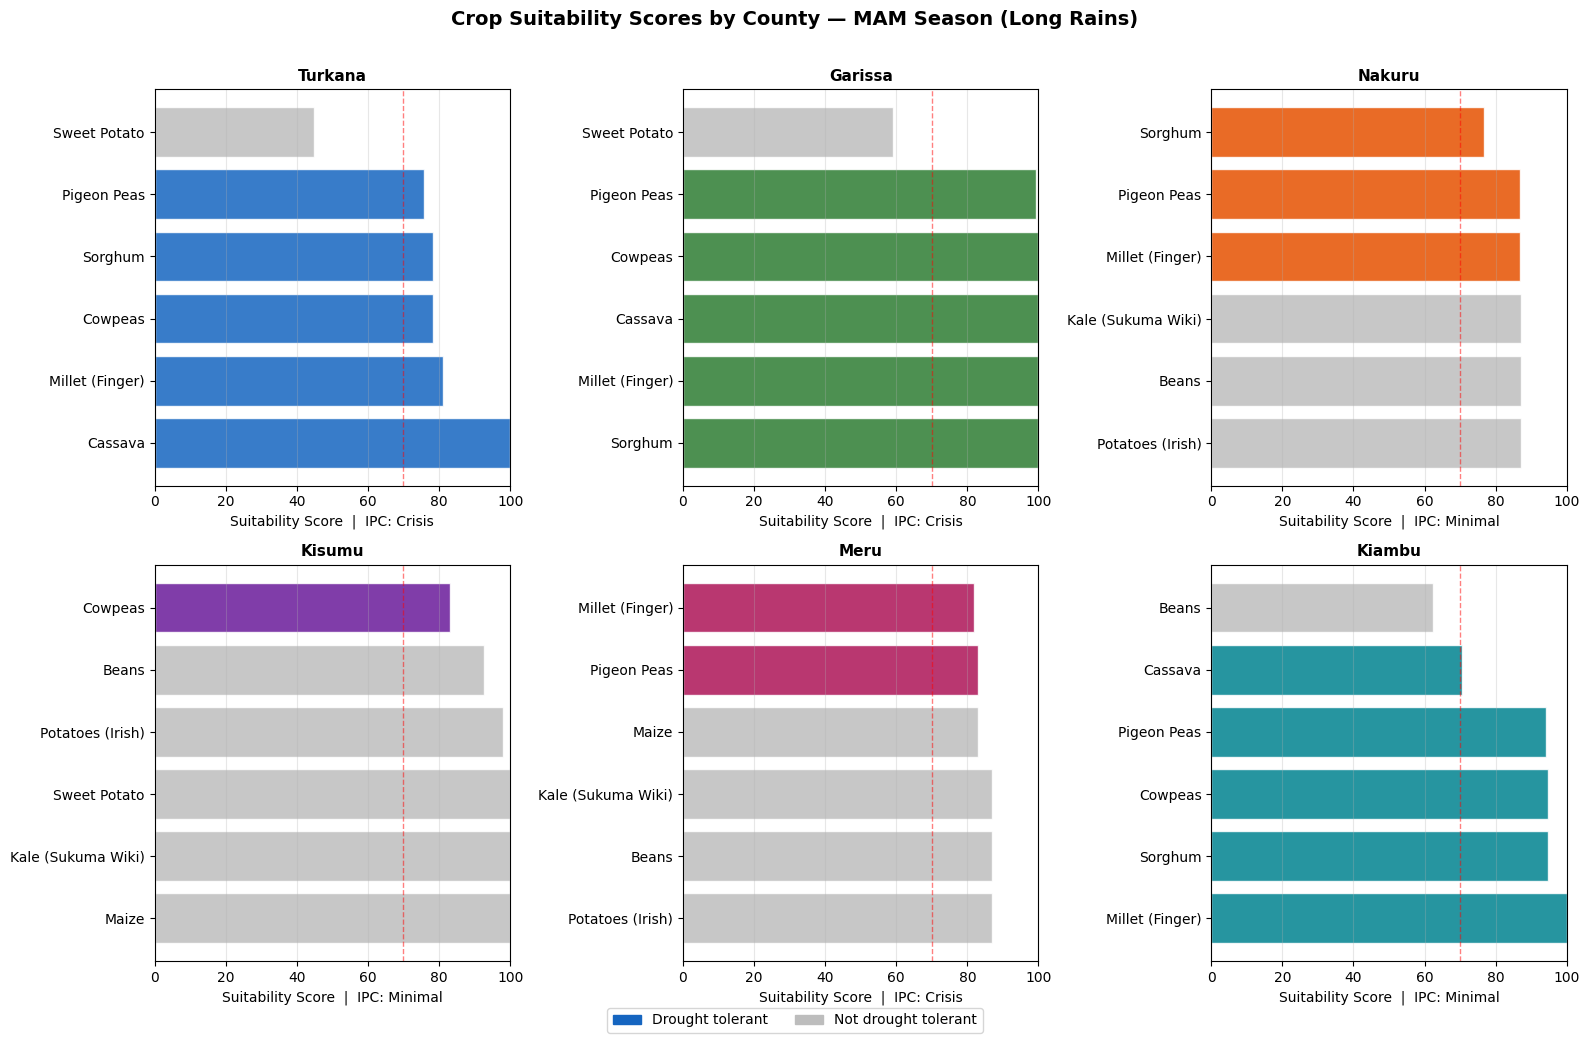

Saved: figures/17_crop_suitability_by_county.png


In [39]:
# Bar chart — crop suitability scores for selected counties
selected_counties = ["Turkana", "Garissa", "Nakuru", "Kisumu", "Meru", "Kiambu"]
season = "MAM"

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colours = ["#1565C0","#2E7D32","#E65100","#6A1B9A","#AD1457","#00838F"]

for ax, county, colour in zip(axes, selected_counties, colours):
    scores = score_crop_suitability(county, season).head(6)
    if scores.empty:
        continue
    bar_colours = [colour if d == "Yes" else "#BDBDBD"
                   for d in scores["drought_tolerant"].map({True:"Yes", False:"No"})]
    bars = ax.barh(scores["crop"], scores["suitability_score"],
                   color=bar_colours, alpha=0.85, edgecolor="white")
    ax.set_xlim(0, 100)
    ax.set_title(f"{county}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Suitability Score (%)")
    ax.axvline(70, color="red", linestyle="--", alpha=0.5, linewidth=1)
    ax.grid(axis="x", alpha=0.3)

    # Add IPC (Integrated Food Security Phase Classification) label
    ipc_row = county_weather[county_weather["county"] == county]
    if not ipc_row.empty:
        ipc_label = ipc_row.iloc[0].get("ipc_phase_label", "")
        ax.set_xlabel(f"Suitability Score  |  IPC: {ipc_label}")

patches = [
    mpatches.Patch(color="#1565C0", label="Drought tolerant"),
    mpatches.Patch(color="#BDBDBD", label="Not drought tolerant"),
]
fig.legend(handles=patches, loc="lower center", ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f"Crop Suitability Scores by County — {season} Season (Long Rains)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/17_crop_suitability_by_county.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/17_crop_suitability_by_county.png")

The chart tells a clear story at a glance — Turkana and Garissa (Crisis counties) get drought-tolerant crops in blue, while Nakuru, Kisumu and Kiambu (Minimal counties) get a wider range including non-drought-tolerant crops in grey.

## Step 9 — WFP (World Food Programme) Price Trends for Key Crops

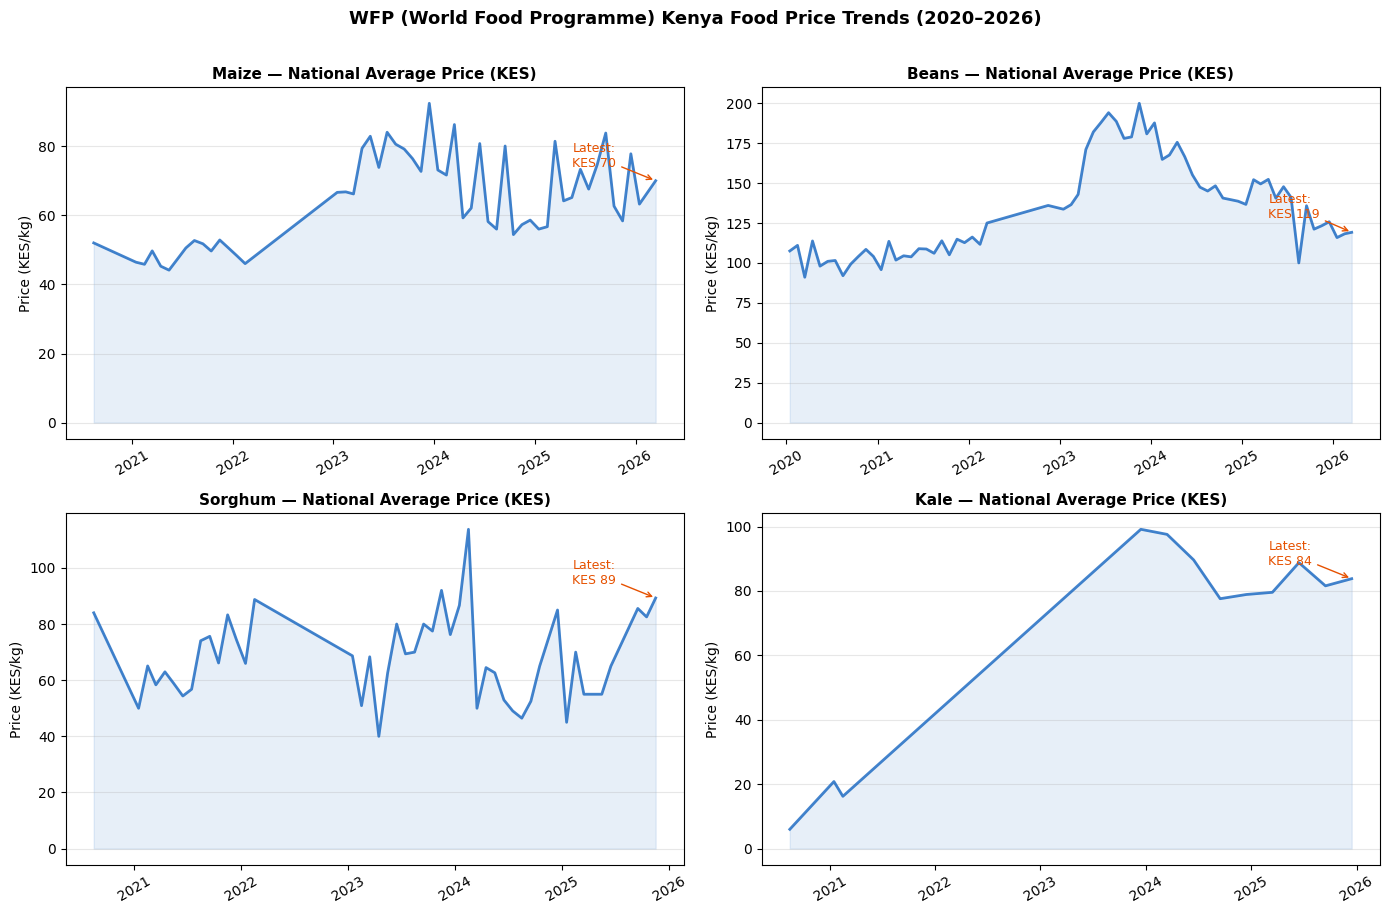

Saved: figures/18_wfp_price_trends.png


In [40]:
# Plot price trends for main crops across Kenya regions
key_crops_wfp = {
    "Maize":  ["Maize", "Maize (white, dry)"],
    "Beans":  ["Beans", "Beans (dry)"],
    "Sorghum":["Sorghum", "Sorghum (white)"],
    "Kale":   ["Kale"],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (crop_name, wfp_names) in zip(axes, key_crops_wfp.items()):
    crop_prices = wfp_prices[
        (wfp_prices["commodity"].isin(wfp_names)) &
        (wfp_prices["date"] >= "2020-01-01") &
        (wfp_prices["pricetype"] == "Retail")
    ].copy()

    if crop_prices.empty:
        crop_prices = wfp_prices[
            (wfp_prices["commodity"].isin(wfp_names)) &
            (wfp_prices["date"] >= "2020-01-01")
        ].copy()

    if crop_prices.empty:
        ax.set_title(f"{crop_name} — No data")
        continue

    monthly = (crop_prices.groupby("date")["price"]
               .mean().reset_index())

    ax.plot(monthly["date"], monthly["price"],
            color="#1565C0", linewidth=2, alpha=0.8)
    ax.fill_between(monthly["date"], monthly["price"],
                    alpha=0.1, color="#1565C0")
    ax.set_title(f"{crop_name} — National Average Price (KES)",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Price (KES/kg)")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

    latest_price = monthly.iloc[-1]["price"]
    ax.annotate(f"Latest:\nKES {latest_price:.0f}",
                xy=(monthly.iloc[-1]["date"], latest_price),
                xytext=(-60, 10), textcoords="offset points",
                fontsize=9, color="#E65100",
                arrowprops=dict(arrowstyle="->", color="#E65100"))

plt.suptitle("WFP (World Food Programme) Kenya Food Price Trends (2020–2026)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/18_wfp_price_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/18_wfp_price_trends.png")


Very informative price charts. Key observations:

Maize peaked at KES 90/kg in 2024 (drought year) and has come down to KES 70 — falling trend
Beans spiked dramatically to KES 200/kg in 2023-2024 and is now falling back to KES 119
Sorghum is volatile but rising recently to KES 89
Kale has risen steadily from KES 8 in 2020 to KES 84 now — a 10x increase over 5 years

These trends directly connect to the IPC food security crisis — when maize and beans prices spike, food insecurity worsens.

## Step 10 — Save Profiles for Streamlit App

In [41]:
# Save county weather profiles
county_weather.to_csv("data/processed/county_profiles.csv", index=False)

# Save recent WFP prices (last 12 months)
recent_wfp = wfp_prices[wfp_prices["date"] >= wfp_prices["date"].max() - pd.DateOffset(months=12)]
recent_wfp.to_csv("data/processed/wfp_prices_recent.csv", index=False)

print("Saved:")
print(f"  data/processed/county_profiles.csv    ({len(county_weather)} counties)")
print(f"  data/processed/wfp_prices_recent.csv  ({len(recent_wfp)} price records)")
print()
print("Notebook 06 Complete ✅")
print()

# Final summary
print("RECOMMENDATION SYSTEM SUMMARY:")
print(f"  Crops in database     : {len(CROPS)}")
print(f"  Counties covered      : {len(county_weather)}")
print(f"  WFP markets available : {wfp_prices['market'].nunique()}")
print(f"  Price records (recent): {len(recent_wfp)}")

Saved:
  data/processed/county_profiles.csv    (46 counties)
  data/processed/wfp_prices_recent.csv  (1682 price records)

Notebook 06 Complete ✅

RECOMMENDATION SYSTEM SUMMARY:
  Crops in database     : 10
  Counties covered      : 46
  WFP markets available : 226
  Price records (recent): 1682
